Day challenge

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")


# ==============================
# 1. Chargement du dataset
# ==============================

df = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1"
)


# ==============================
# 2. Première exploration des données
# ==============================

print("Dimensions du dataset :", df.shape)

print("\nListe des colonnes :")
print(df.columns.tolist())

print("\nInformations générales sur le dataset :")
df.info()

print("\nStatistiques descriptives :")
display(df.describe())

print("\nValeurs manquantes par colonne :")
display(df.isnull().sum())


# ==============================
# 3. Nettoyage des données
# ==============================

# Vérifier le nombre de lignes dupliquées
nombre_doublons = df.duplicated().sum()
print("Nombre de lignes dupliquées :", nombre_doublons)

# Supprimer les doublons s'il y en a
df = df.drop_duplicates()

# Vérifier à nouveau les valeurs manquantes
print("\nValeurs manquantes après suppression des doublons :")
display(df.isnull().sum())

# Remplacer les codes postaux manquants par 0
# Ce choix permet de conserver les lignes, car le code postal n'est pas essentiel pour toutes les analyses.
if "Postal Code" in df.columns:
    df["Postal Code"] = df["Postal Code"].fillna(0)


# ==============================
# 4. Conversion des dates
# ==============================

date_columns = ["Order Date", "Ship Date"]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print("\nTypes des colonnes de dates après conversion :")
display(df[date_columns].dtypes)


# ==============================
# 5. Création de nouvelles variables
# ==============================

# Le profit margin permet de mesurer la rentabilité par rapport aux ventes.
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

# Ces colonnes serviront à analyser l'évolution des ventes dans le temps.
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month-Year"] = df["Order Date"].dt.to_period("M")

print("\nAperçu des nouvelles colonnes créées :")
display(df[["Sales", "Profit", "Profit Margin", "Order Year", "Order Month"]].head())


# ==============================
# 6. Vérification finale
# ==============================

print("\nDimensions finales du dataset après préparation :", df.shape)

print("\nValeurs manquantes finales :")
display(df.isnull().sum())

Dimensions du dataset : (9994, 21)

Liste des colonnes :
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Informations générales sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  St

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000



Valeurs manquantes par colonne :


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Nombre de lignes dupliquées : 0

Valeurs manquantes après suppression des doublons :


...

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]



Aperçu des nouvelles colonnes créées :


,Sales,Profit,Profit Margin,Order Year,Order Month
0,261.9600,41.9136,16.00,2016,11
1,731.9400,219.5820,30.00,2016,11
2,14.6200,6.8714,47.00,2016,6
3,957.5775,-383.0310,-40.00,2015,10
4,22.3680,2.5164,11.25,2015,10



Dimensions finales du dataset après préparation : (9994, 25)

Valeurs manquantes finales :


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [28]:
# ==============================
# Analyse de l'évolution mensuelle des ventes
# ==============================

# Regrouper les ventes par mois et par catégorie
# Cela permet d'observer l'évolution des ventes dans le temps.
monthly_sales = (
    df.groupby(["Order Month-Year", "Category"])["Sales"]
    .sum()
    .reset_index()
)

# Convertir la période mois-année en vraie date pour faciliter l'affichage du graphique
monthly_sales["Date"] = monthly_sales["Order Month-Year"].dt.to_timestamp()


# Fonction permettant d'afficher l'évolution des ventes selon la catégorie choisie
def plot_monthly_sales(category="Toutes les catégories"):
    plt.figure(figsize=(12, 6))

    if category == "Toutes les catégories":
        # Calculer les ventes mensuelles toutes catégories confondues
        total_monthly_sales = df.groupby("Order Month-Year")["Sales"].sum()

        plt.plot(
            total_monthly_sales.index.to_timestamp(),
            total_monthly_sales.values,
            marker="o",
            linewidth=2,
            markersize=4
        )

        plt.title(
            "Évolution mensuelle des ventes - Toutes les catégories",
            fontsize=16,
            fontweight="bold"
        )

    else:
        # Filtrer les données selon la catégorie sélectionnée
        category_data = monthly_sales[monthly_sales["Category"] == category]

        plt.plot(
            category_data["Date"],
            category_data["Sales"],
            marker="o",
            linewidth=2,
            markersize=4
        )

        plt.title(
            f"Évolution mensuelle des ventes - Catégorie : {category}",
            fontsize=16,
            fontweight="bold"
        )

    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Ventes totales ($)", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Création du menu interactif pour choisir une catégorie de produit
categories = ["Toutes les catégories"] + list(df["Category"].unique())

category_dropdown = Dropdown(
    options=categories,
    value="Toutes les catégories",
    description="Catégorie :"
)

interact(plot_monthly_sales, category=category_dropdown);

interactive(children=(Dropdown(description='Catégorie :', options=('Toutes les catégories', 'Furniture', 'Offi…

In [29]:
# ==============================
# Analyse géographique des ventes
# ==============================

# Regrouper les ventes par État afin d'identifier les zones les plus performantes
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=True)
)


# Fonction pour afficher les meilleurs États selon le chiffre d'affaires
def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))

    # Sélectionner les Top N États avec les ventes les plus élevées
    top_states = state_sales.tail(top_n)

    # Créer un graphique en barres horizontales
    plt.barh(
        range(len(top_states)),
        top_states.values
    )

    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel("Ventes totales ($)", fontsize=12)
    plt.ylabel("État", fontsize=12)
    plt.title(
        f"Top {top_n} des États avec les meilleures ventes",
        fontsize=16,
        fontweight="bold"
    )

    # Ajouter les montants à côté de chaque barre
    for i, (state, value) in enumerate(top_states.items()):
        plt.text(
            value + max(top_states.values) * 0.01,
            i,
            f"${value:,.0f}",
            va="center",
            fontsize=10
        )

    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Nombre total d'États analysés : {len(state_sales)}")
    print(f"Les {top_n} premiers États représentent ${top_states.sum():,.0f} de ventes.")


# Création d'un curseur interactif pour choisir le nombre d'États à afficher
top_n_slider = IntSlider(
    min=5,
    max=25,
    value=10,
    description="Top États :"
)

interact(plot_top_states, top_n=top_n_slider);

interactive(children=(IntSlider(value=10, description='Top États :', max=25, min=5), Output()), _dom_classes=(…

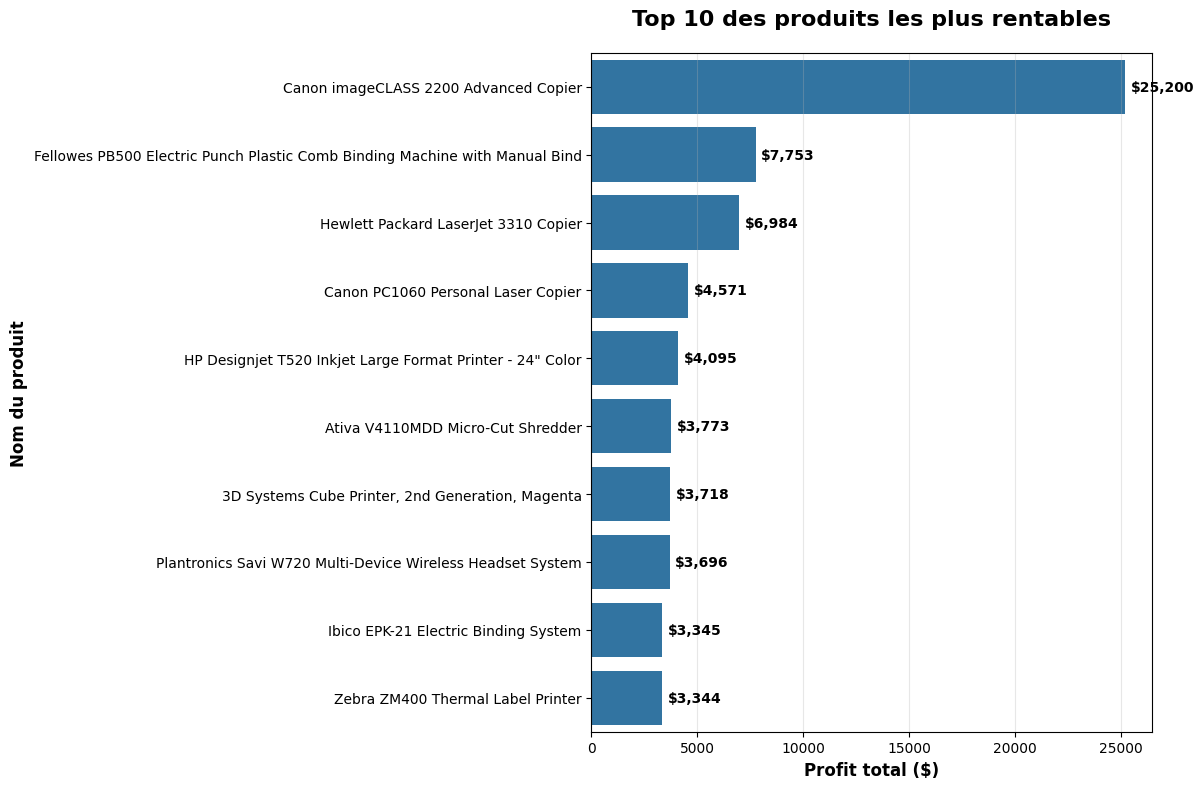

Résumé de l'analyse des produits :
• Le produit le plus rentable génère un profit de : $25,200
• Les 10 produits les plus rentables génèrent au total : $66,479
• Le profit moyen des 10 meilleurs produits est de : $6,648


In [30]:
# ==============================
# Analyse des produits les plus rentables
# ==============================

# Regrouper les profits par produit afin d'identifier les produits qui rapportent le plus
product_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Création du graphique
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=product_profit.values,
    y=product_profit.index,
    orient="h"
)

# Personnalisation du graphique
plt.title(
    "Top 10 des produits les plus rentables",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Profit total ($)", fontsize=12, fontweight="bold")
plt.ylabel("Nom du produit", fontsize=12, fontweight="bold")

# Ajouter les valeurs exactes à côté des barres
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(
        profit + max(product_profit.values) * 0.01,
        i,
        f"${profit:,.0f}",
        va="center",
        fontweight="bold",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# Résumé des principaux résultats
print("Résumé de l'analyse des produits :")
print(f"• Le produit le plus rentable génère un profit de : ${product_profit.iloc[0]:,.0f}")
print(f"• Les 10 produits les plus rentables génèrent au total : ${product_profit.sum():,.0f}")
print(f"• Le profit moyen des 10 meilleurs produits est de : ${product_profit.mean():,.0f}")

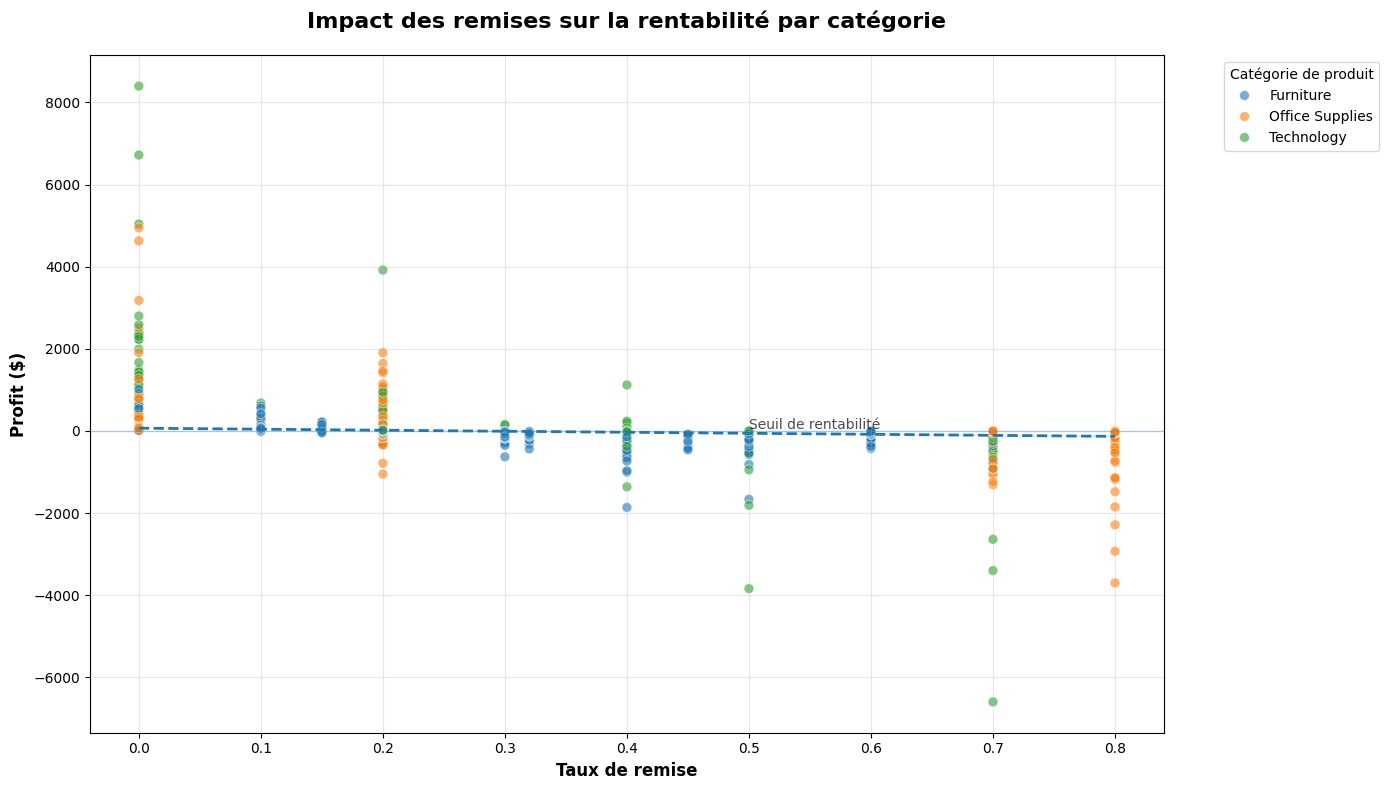

Analyse de l'effet des remises :
• Nombre de transactions avec une remise supérieure à 20 % : 1,393
• Profit moyen pour ces fortes remises : $-97.18
• Pourcentage de pertes parmi ces transactions : 96.8%

Impact des fortes remises par catégorie :
• Furniture : profit moyen avec une remise > 20 % = $-100.51
• Office Supplies : profit moyen avec une remise > 20 % = $-69.32
• Technology : profit moyen avec une remise > 20 % = $-197.42


In [31]:
# ==============================
# Analyse de l'impact des remises sur le profit
# ==============================

plt.figure(figsize=(14, 8))

# Nuage de points pour observer la relation entre la remise et le profit
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.6,
    s=50
)

# Ajouter une ligne de tendance générale
sns.regplot(
    data=df,
    x="Discount",
    y="Profit",
    scatter=False,
    line_kws={"linewidth": 2, "linestyle": "--"}
)

# Personnalisation du graphique
plt.title(
    "Impact des remises sur la rentabilité par catégorie",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Taux de remise", fontsize=12, fontweight="bold")
plt.ylabel("Profit ($)", fontsize=12, fontweight="bold")

# Ligne de référence : profit nul
plt.axhline(y=0, linestyle="-", alpha=0.3, linewidth=1)
plt.text(
    0.5,
    50,
    "Seuil de rentabilité",
    fontsize=10,
    alpha=0.7
)

plt.grid(True, alpha=0.3)
plt.legend(
    title="Catégorie de produit",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ==============================
# Résumé chiffré de l'analyse
# ==============================

print("Analyse de l'effet des remises :")

# Sélectionner les transactions avec une remise supérieure à 20 %
high_discount = df[df["Discount"] > 0.2]

print(f"• Nombre de transactions avec une remise supérieure à 20 % : {len(high_discount):,}")
print(f"• Profit moyen pour ces fortes remises : ${high_discount['Profit'].mean():.2f}")
print(f"• Pourcentage de pertes parmi ces transactions : {(high_discount['Profit'] < 0).mean() * 100:.1f}%")


# Analyse par catégorie
print("\nImpact des fortes remises par catégorie :")

for category in df["Category"].unique():
    category_data = df[df["Category"] == category]
    high_discount_category = category_data[category_data["Discount"] > 0.2]

    if len(high_discount_category) > 0:
        average_profit = high_discount_category["Profit"].mean()

        print(
            f"• {category} : profit moyen avec une remise > 20 % = ${average_profit:.2f}"
        )

In [32]:
# ==============================
# Comparaison entre Matplotlib et Seaborn
# ==============================

print("=== COMPARAISON ENTRE MATPLOTLIB ET SEABORN ===")
print()

# Points forts de Matplotlib observés dans notre analyse
print("POINTS FORTS DE MATPLOTLIB :")
print("• Permet un contrôle précis sur les graphiques")
print("• S'intègre bien avec les widgets interactifs")
print("• Facilite la personnalisation des titres, axes et annotations")
print("• Convient bien aux graphiques simples et aux analyses dynamiques")
print()

# Points forts de Seaborn observés dans notre analyse
print("POINTS FORTS DE SEABORN :")
print("• Produit des graphiques plus esthétiques rapidement")
print("• Facilite l'analyse statistique avec des fonctions comme regplot")
print("• Gère automatiquement les couleurs et les légendes")
print("• Est très pratique pour comparer des catégories")
print()


# ==============================
# Comparaison simple du temps d'exécution
# ==============================

print("COMPARAISON DU TEMPS D'EXÉCUTION :")

import time

# Temps d'exécution d'un graphique simple avec Matplotlib
start = time.time()

plt.figure(figsize=(8, 6))
plt.plot(df.groupby("Order Year")["Sales"].sum())
plt.close()

matplotlib_time = time.time() - start


# Temps d'exécution d'un graphique similaire avec Seaborn
start = time.time()

yearly_sales = df.groupby("Order Year")["Sales"].sum().reset_index()

plt.figure(figsize=(8, 6))
sns.lineplot(
    data=yearly_sales,
    x="Order Year",
    y="Sales"
)
plt.close()

seaborn_time = time.time() - start


print(f"• Temps avec Matplotlib : {matplotlib_time:.4f} secondes")
print(f"• Temps avec Seaborn : {seaborn_time:.4f} secondes")


# ==============================
# Conclusion personnelle
# ==============================

print()
print("CONCLUSION :")
print("Matplotlib est utile lorsque l'on veut personnaliser fortement un graphique ou créer des visualisations interactives simples.")
print("Seaborn est plus adapté lorsque l'on veut obtenir rapidement des graphiques propres, lisibles et orientés analyse statistique.")
print("Dans ce projet, les deux bibliothèques sont complémentaires : Matplotlib aide à contrôler les graphiques, tandis que Seaborn facilite la communication visuelle des résultats.")

=== COMPARAISON ENTRE MATPLOTLIB ET SEABORN ===

POINTS FORTS DE MATPLOTLIB :
• Permet un contrôle précis sur les graphiques
• S'intègre bien avec les widgets interactifs
• Facilite la personnalisation des titres, axes et annotations
• Convient bien aux graphiques simples et aux analyses dynamiques

POINTS FORTS DE SEABORN :
• Produit des graphiques plus esthétiques rapidement
• Facilite l'analyse statistique avec des fonctions comme regplot
• Gère automatiquement les couleurs et les légendes
• Est très pratique pour comparer des catégories

COMPARAISON DU TEMPS D'EXÉCUTION :
• Temps avec Matplotlib : 0.0158 secondes
• Temps avec Seaborn : 0.0619 secondes

CONCLUSION :
Matplotlib est utile lorsque l'on veut personnaliser fortement un graphique ou créer des visualisations interactives simples.
Seaborn est plus adapté lorsque l'on veut obtenir rapidement des graphiques propres, lisibles et orientés analyse statistique.
Dans ce projet, les deux bibliothèques sont complémentaires : Matplot

In [33]:
# ==============================
# Résumé exécutif des principaux résultats
# ==============================

print("=== RÉSUMÉ EXÉCUTIF - PRINCIPAUX RÉSULTATS ===")
print()


# ==============================
# 1. Performance globale des ventes
# ==============================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_profit_margin = (total_profit / total_sales) * 100

print("📊 PERFORMANCE COMMERCIALE GLOBALE :")
print(f"• Chiffre d'affaires total : ${total_sales:,.0f}")
print(f"• Profit total : ${total_profit:,.0f}")
print(f"• Marge bénéficiaire globale : {overall_profit_margin:.1f}%")
print()


# ==============================
# 2. Performance géographique
# ==============================

top_state = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]

top_5_states_sales = state_sales.tail(5).sum()
top_5_states_percentage = (top_5_states_sales / total_sales) * 100

print("🗺️ PERFORMANCE GÉOGRAPHIQUE :")
print(f"• État le plus performant : {top_state} avec ${top_state_sales:,.0f} de ventes")
print(f"• Les 5 meilleurs États représentent {top_5_states_percentage:.1f}% du chiffre d'affaires total")
print()


# ==============================
# 3. Performance des produits
# ==============================

top_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

most_profitable_product = product_profit.index[0]

print("🏆 PERFORMANCE DES PRODUITS :")
print(f"• Catégorie qui génère le plus de ventes : {top_category}")
print(f"• Produit le plus rentable : {most_profitable_product}")
print()


# ==============================
# 4. Analyse de la stratégie de remise
# ==============================

high_discount_data = df[df["Discount"] > 0.2]
high_discount_loss_rate = (high_discount_data["Profit"] < 0).mean() * 100

print("💰 ANALYSE DES REMISES :")
print(f"• {high_discount_loss_rate:.1f}% des ventes avec une remise supérieure à 20 % entraînent une perte")
print("• Recommandation : limiter les remises standards à 20 % pour protéger la rentabilité")
print()


# ==============================
# 5. Recommandations stratégiques
# ==============================

print("✅ RECOMMANDATIONS :")
print("• Renforcer les actions commerciales dans les États les plus performants")
print("• Mettre en avant les produits les plus rentables dans les campagnes marketing")
print("• Surveiller les remises élevées, surtout lorsqu'elles dépassent 20 %")
print("• Utiliser les analyses mensuelles pour mieux anticiper les périodes de forte ou faible vente")

=== RÉSUMÉ EXÉCUTIF - PRINCIPAUX RÉSULTATS ===

📊 PERFORMANCE COMMERCIALE GLOBALE :
• Chiffre d'affaires total : $2,297,201
• Profit total : $286,397
• Marge bénéficiaire globale : 12.5%

🗺️ PERFORMANCE GÉOGRAPHIQUE :
• État le plus performant : California avec $457,688 de ventes
• Les 5 meilleurs États représentent 52.0% du chiffre d'affaires total

🏆 PERFORMANCE DES PRODUITS :
• Catégorie qui génère le plus de ventes : Technology
• Produit le plus rentable : Canon imageCLASS 2200 Advanced Copier

💰 ANALYSE DES REMISES :
• 96.8% des ventes avec une remise supérieure à 20 % entraînent une perte
• Recommandation : limiter les remises standards à 20 % pour protéger la rentabilité

✅ RECOMMANDATIONS :
• Renforcer les actions commerciales dans les États les plus performants
• Mettre en avant les produits les plus rentables dans les campagnes marketing
• Surveiller les remises élevées, surtout lorsqu'elles dépassent 20 %
• Utiliser les analyses mensuelles pour mieux anticiper les périodes d

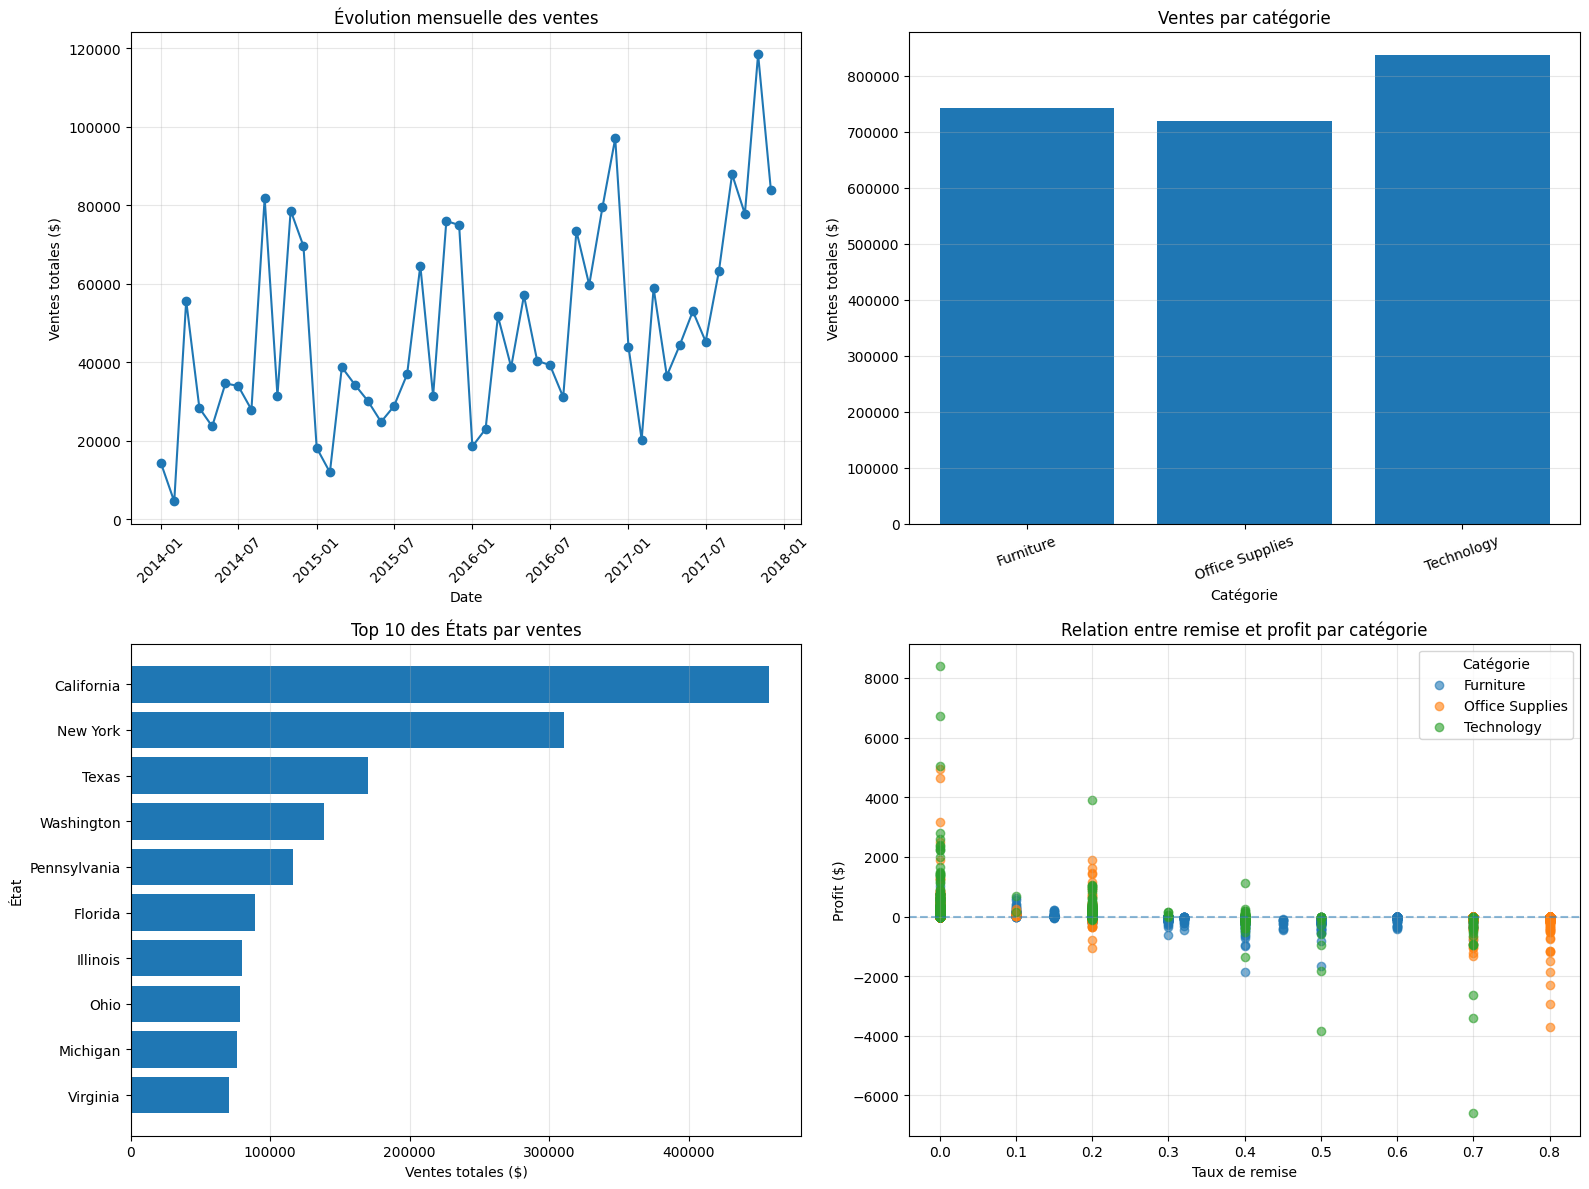

In [34]:
# ==============================
# Bonus : Tableau de bord synthétique
# ==============================

def create_dashboard():
    # Créer une figure avec 4 graphiques
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # ------------------------------
    # Graphique 1 : évolution mensuelle des ventes
    # ------------------------------
    monthly_total = df.groupby("Order Month-Year")["Sales"].sum()

    ax1.plot(
        monthly_total.index.to_timestamp(),
        monthly_total.values,
        marker="o"
    )

    ax1.set_title("Évolution mensuelle des ventes")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Ventes totales ($)")
    ax1.tick_params(axis="x", rotation=45)
    ax1.grid(True, alpha=0.3)


    # ------------------------------
    # Graphique 2 : ventes par catégorie
    # ------------------------------
    category_sales = df.groupby("Category")["Sales"].sum()

    ax2.bar(
        category_sales.index,
        category_sales.values
    )

    ax2.set_title("Ventes par catégorie")
    ax2.set_xlabel("Catégorie")
    ax2.set_ylabel("Ventes totales ($)")
    ax2.tick_params(axis="x", rotation=20)
    ax2.grid(axis="y", alpha=0.3)


    # ------------------------------
    # Graphique 3 : top 10 des États par ventes
    # ------------------------------
    top_10_states = state_sales.tail(10)

    ax3.barh(
        range(len(top_10_states)),
        top_10_states.values
    )

    ax3.set_yticks(range(len(top_10_states)))
    ax3.set_yticklabels(top_10_states.index)
    ax3.set_title("Top 10 des États par ventes")
    ax3.set_xlabel("Ventes totales ($)")
    ax3.set_ylabel("État")
    ax3.grid(axis="x", alpha=0.3)


    # ------------------------------
    # Graphique 4 : remise et profit par catégorie
    # ------------------------------
    for category in df["Category"].unique():
        category_data = df[df["Category"] == category]

        ax4.scatter(
            category_data["Discount"],
            category_data["Profit"],
            label=category,
            alpha=0.6
        )

    ax4.set_title("Relation entre remise et profit par catégorie")
    ax4.set_xlabel("Taux de remise")
    ax4.set_ylabel("Profit ($)")
    ax4.axhline(y=0, linestyle="--", alpha=0.5)
    ax4.legend(title="Catégorie")
    ax4.grid(True, alpha=0.3)


    # Ajuster l'espacement entre les graphiques
    plt.tight_layout()
    plt.show()


# Afficher le tableau de bord
create_dashboard()

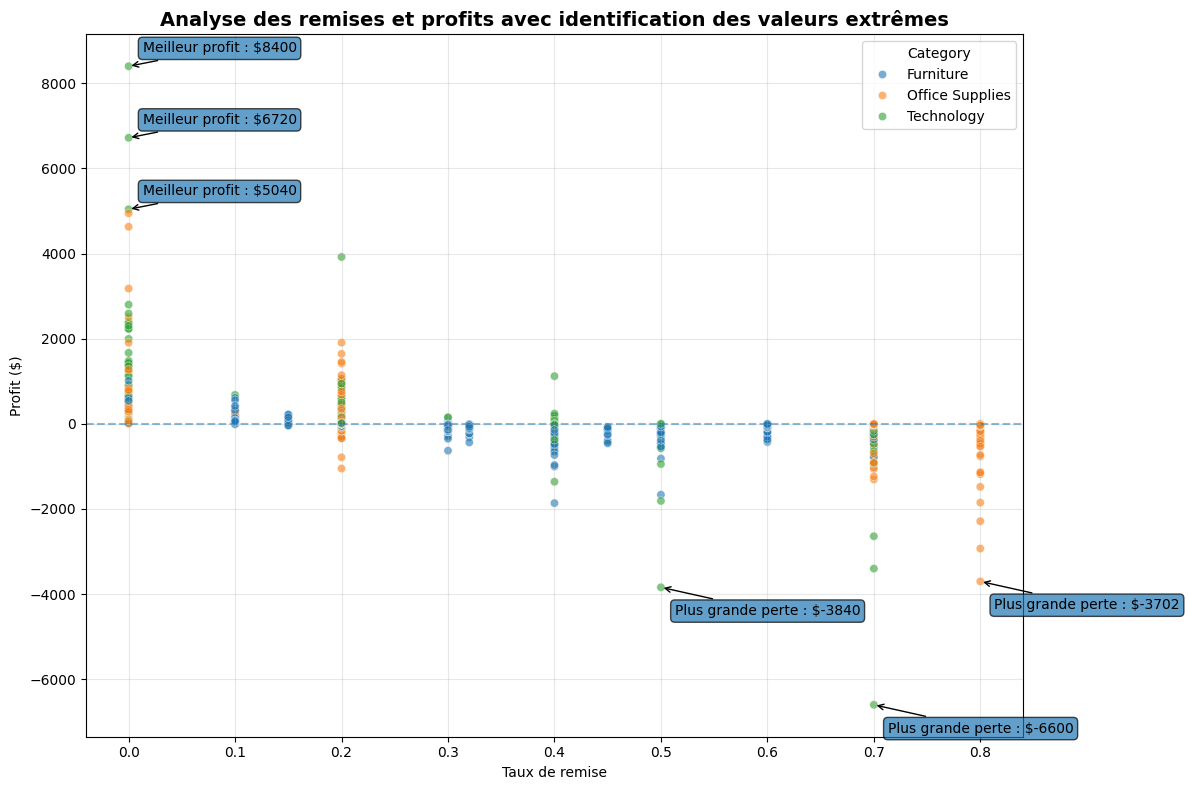

In [35]:
# ==============================
# Bonus : Analyse des valeurs extrêmes avec annotations
# ==============================

plt.figure(figsize=(12, 8))

# Créer un nuage de points pour visualiser la relation entre remise et profit
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.6
)

# Identifier les 3 transactions les plus profitables et les 3 moins profitables
top_3_profitable = df.nlargest(3, "Profit")
bottom_3_profitable = df.nsmallest(3, "Profit")


# Annoter les transactions les plus profitables
for idx, row in top_3_profitable.iterrows():
    plt.annotate(
        f'Meilleur profit : ${row["Profit"]:.0f}',
        xy=(row["Discount"], row["Profit"]),
        xytext=(10, 10),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.3",
            alpha=0.7
        ),
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0"
        )
    )


# Annoter les transactions les moins profitables
for idx, row in bottom_3_profitable.iterrows():
    plt.annotate(
        f'Plus grande perte : ${row["Profit"]:.0f}',
        xy=(row["Discount"], row["Profit"]),
        xytext=(10, -20),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.3",
            alpha=0.7
        ),
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0"
        )
    )


plt.title(
    "Analyse des remises et profits avec identification des valeurs extrêmes",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Taux de remise")
plt.ylabel("Profit ($)")
plt.axhline(y=0, linestyle="--", alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# ==============================
# Bonus : comparaison avec Plotly
# ==============================

import plotly.express as px
import plotly.graph_objects as go


# Créer une version interactive du graphique Remise vs Profit avec Plotly
fig = px.scatter(
    df,
    x="Discount",
    y="Profit",
    color="Category",
    hover_data=["Product Name", "Sales"],
    title="Analyse interactive de l'impact des remises sur le profit"
)

# Ajouter une ligne de tendance pour mieux visualiser la relation générale
trendline_fig = px.scatter(
    df,
    x="Discount",
    y="Profit",
    trendline="ols"
)

fig.add_traces(trendline_fig.data[1])

fig.show()


# ==============================
# Comparaison entre Plotly et Matplotlib
# ==============================

print("=== COMPARAISON ENTRE PLOTLY ET MATPLOTLIB ===")
print()

print("POINTS FORTS DE PLOTLY :")
print("• Offre une interactivité directe : zoom, déplacement, survol des points")
print("• Permet d'afficher des informations détaillées au passage de la souris")
print("• Produit des graphiques modernes et faciles à explorer")
print("• Est pratique pour présenter des résultats à un public non technique")
print()

print("POINTS FORTS DE MATPLOTLIB + IPYWIDGETS :")
print("• Donne plus de contrôle sur la personnalisation des graphiques")
print("• S'intègre bien dans les notebooks Jupyter")
print("• Permet de créer des visualisations interactives simples avec des widgets")
print("• Est très utilisé pour l'analyse de données en Python")
print()

print("CONCLUSION :")
print("Plotly est très pratique pour explorer les données de manière interactive.")
print("Matplotlib reste utile lorsqu'on veut contrôler précisément la construction du graphique.")
print("Dans ce projet, Plotly sert de bonus pour rendre l'analyse plus dynamique et plus facile à explorer.")

=== COMPARAISON ENTRE PLOTLY ET MATPLOTLIB ===

POINTS FORTS DE PLOTLY :
• Offre une interactivité directe : zoom, déplacement, survol des points
• Permet d'afficher des informations détaillées au passage de la souris
• Produit des graphiques modernes et faciles à explorer
• Est pratique pour présenter des résultats à un public non technique

POINTS FORTS DE MATPLOTLIB + IPYWIDGETS :
• Donne plus de contrôle sur la personnalisation des graphiques
• S'intègre bien dans les notebooks Jupyter
• Permet de créer des visualisations interactives simples avec des widgets
• Est très utilisé pour l'analyse de données en Python

CONCLUSION :
Plotly est très pratique pour explorer les données de manière interactive.
Matplotlib reste utile lorsqu'on veut contrôler précisément la construction du graphique.
Dans ce projet, Plotly sert de bonus pour rendre l'analyse plus dynamique et plus facile à explorer.
